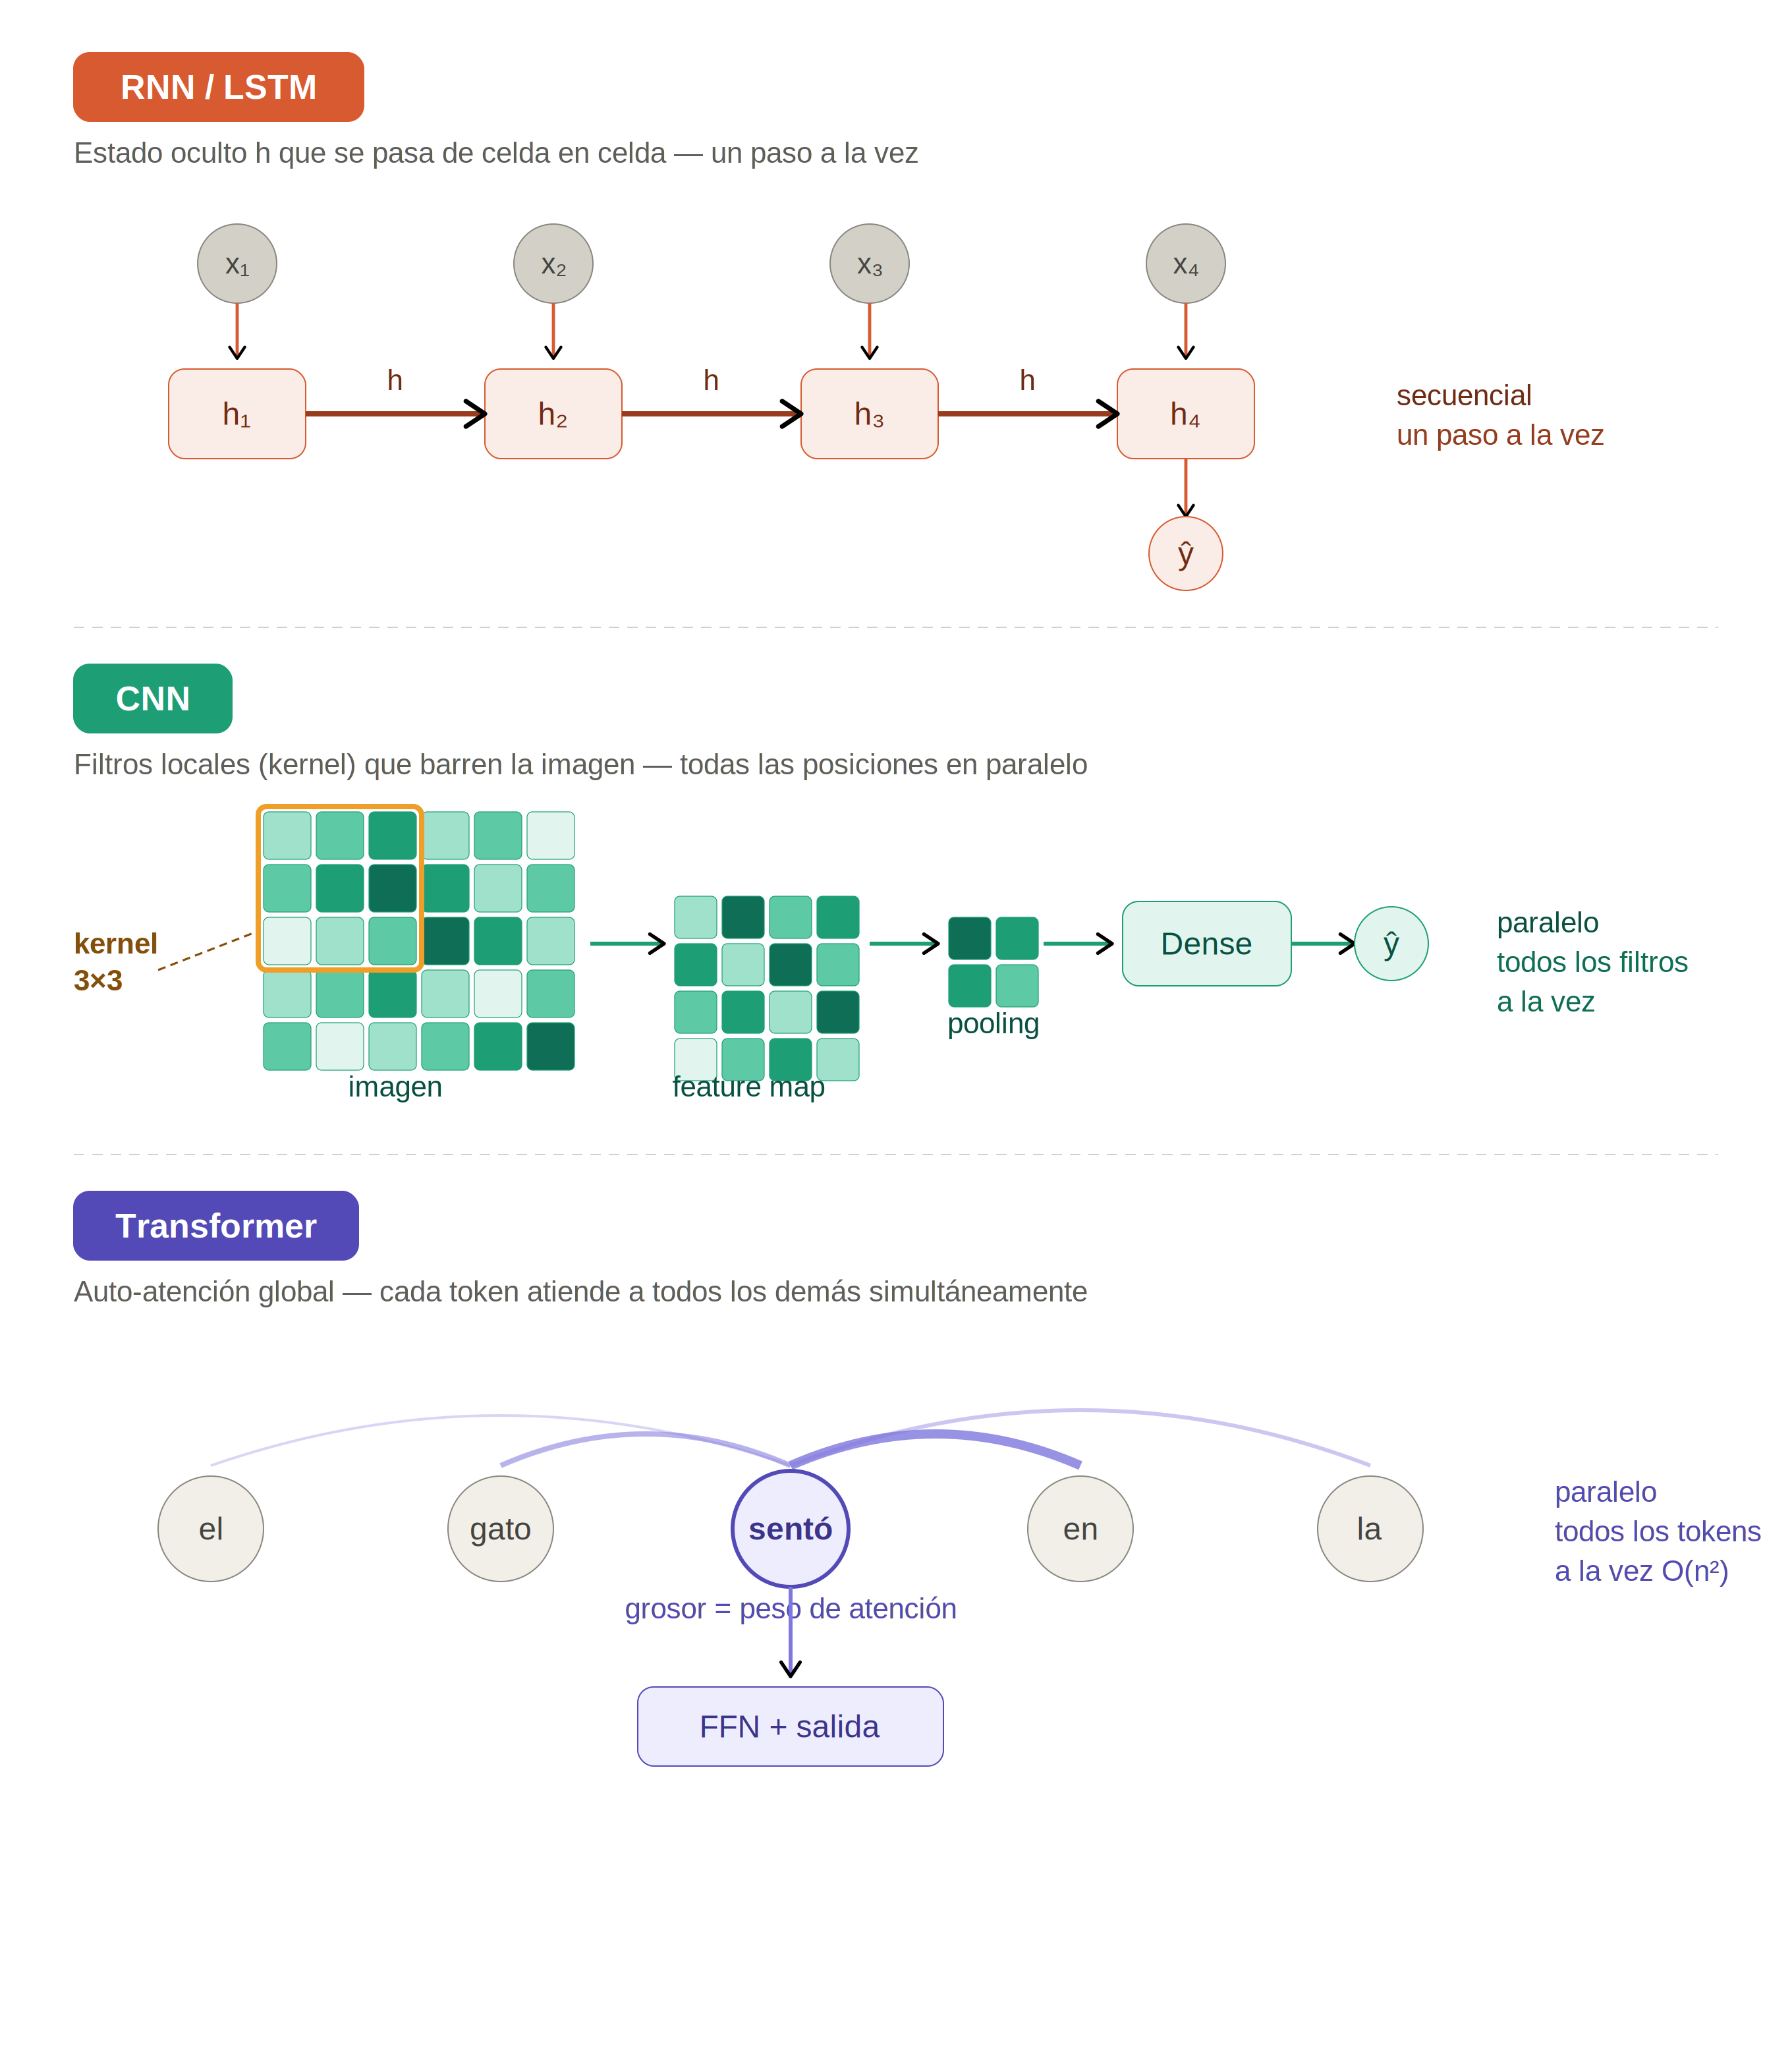

#Código CNN

Dispositivo: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (b

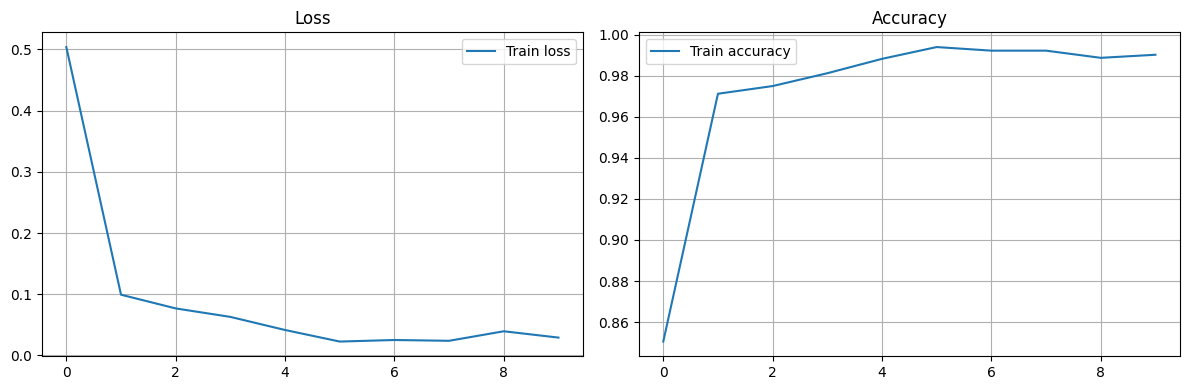

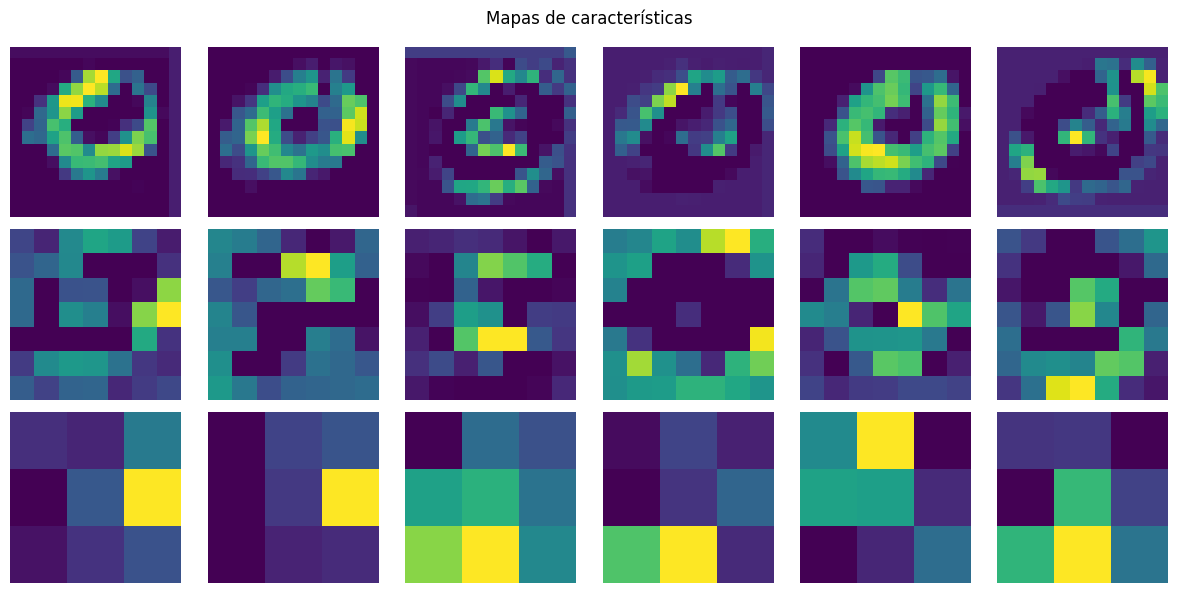

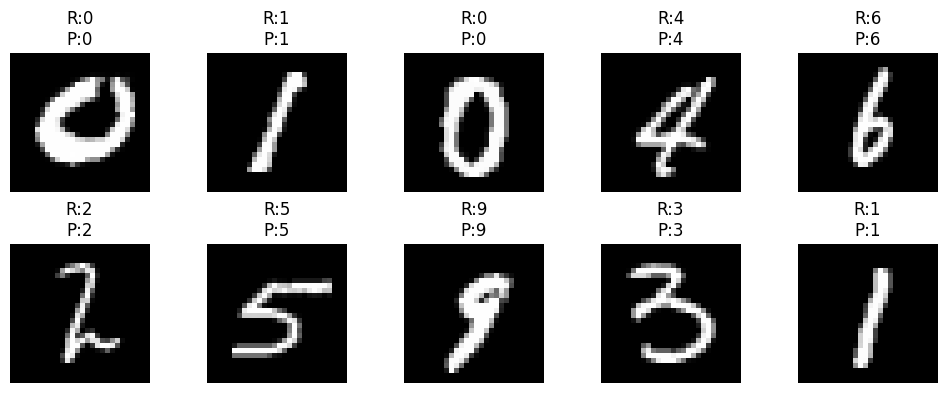

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

from sklearn.metrics import f1_score

# =====================================================
# 1. Configuración
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

batch_size = 64
epochs = 10
lr = 1e-3

# =====================================================
# 2. Cargar y preprocesar datos
# =====================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Subset para acelerar
dataset = Subset(dataset, range(5000))

# Separar train / test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# =====================================================
# 3. CNN original en PyTorch
# =====================================================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        f1 = self.block1(x)
        f2 = self.block2(f1)
        f3 = self.block3(f2)
        out = self.classifier(f3)
        return out

model = CNN().to(device)
print(model)

# =====================================================
# 4. Compilar equivalente: loss + optimizer
# =====================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# =====================================================
# 5. Entrenar
# =====================================================

train_losses = []
train_accs = []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total

    train_losses.append(avg_loss)
    train_accs.append(acc)

    print(f"Época {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

# =====================================================
# 6. Predecir
# =====================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# =====================================================
# 7. Evaluar
# =====================================================

f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nF1-macro: {f1:.4f}")

# =====================================================
# 8. Curvas de entrenamiento
# =====================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train loss")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# =====================================================
# 9. Feature maps
# =====================================================

image, label = test_dataset[0]
image_batch = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    f1 = model.block1(image_batch)
    f2 = model.block2(f1)
    f3 = model.block3(f2)

features = [f1.cpu(), f2.cpu(), f3.cpu()]

plt.figure(figsize=(12, 6))

for i, fmap in enumerate(features):
    for j in range(6):
        plt.subplot(3, 6, i * 6 + j + 1)
        plt.imshow(fmap[0, j, :, :], cmap="viridis")
        plt.axis("off")
        if j == 0:
            plt.ylabel(f"Bloque {i+1}")

plt.suptitle("Mapas de características")
plt.tight_layout()
plt.show()

# =====================================================
# 10. Predicciones
# =====================================================

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

images = images.cpu()
labels = labels.numpy()

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"R:{labels[i]}\nP:{preds[i]}")

plt.tight_layout()
plt.show()